Imports et chargements

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df_mat = pd.read_csv("../dataset/student-mat.csv")

df_por = pd.read_csv("../dataset/student-por.csv")

print("Math dataset :", df_mat.shape)
print("Portuguese dataset :", df_por.shape)

Math dataset : (395, 33)
Portuguese dataset : (649, 33)


Ce code charge les datasets Math et Portugais et affiche leurs dimensions. Il vérifie que les données sont disponibles pour les analyses suivantes.

Distribution des notes

Ce code affiche la distribution des notes finales G3 pour les deux datasets, afin de comparer leur dispersion et leur forme.

Ce graphique montre la répartition de G3 pour Maths et Portugais, utile pour voir la variation des notes finales avant les analyses croisées.

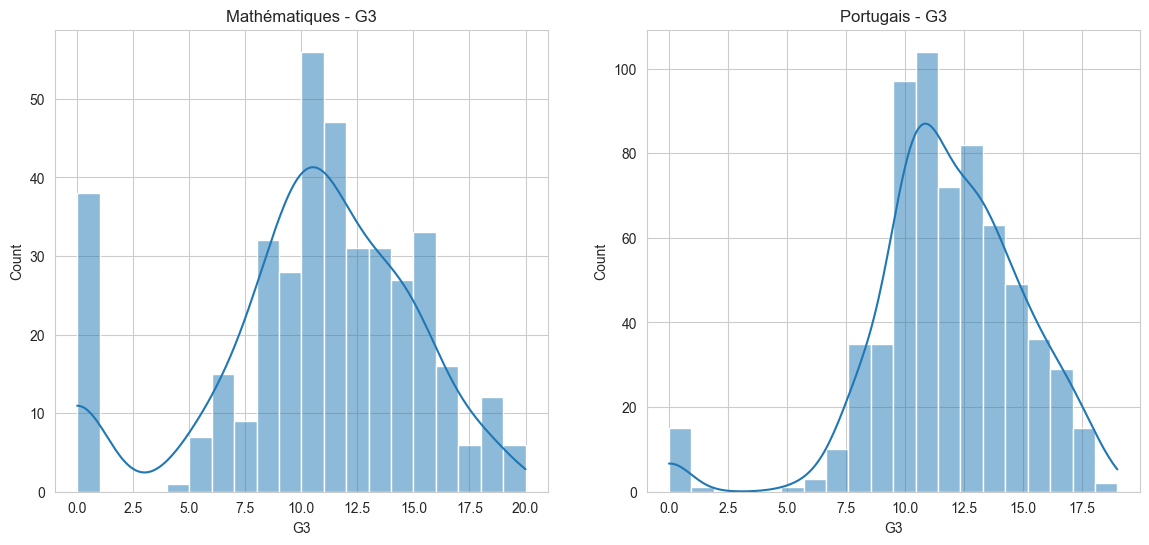

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.histplot(
    df_mat["G3"],
    bins=20,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Mathématiques - G3")

sns.histplot(
    df_por["G3"],
    bins=20,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Portugais - G3")

plt.show()

La heatmap identifie les variables les plus corrélées avec G3 et aide à repérer des facteurs potentiels d'influence avant d'investiguer alcool, absences et autres.

Heatmaps corrélations

Cette cellule calcule et affiche les corrélations entre les variables numériques pour repérer les facteurs les plus liés à G3.

Ces boxplots montrent comment la consommation d'alcool en weekend influence G3 dans chaque dataset.

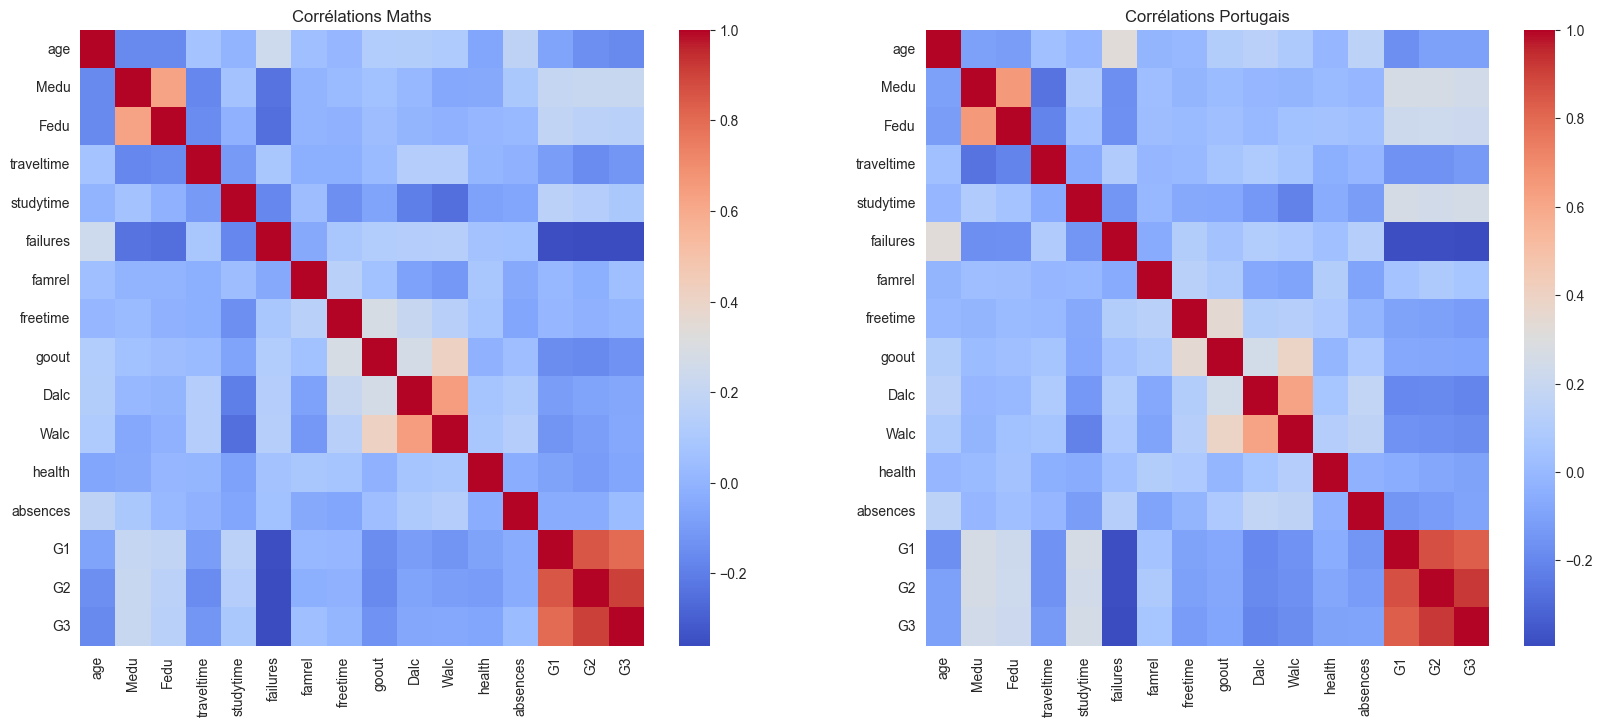

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(20,8))

corr_mat = df_mat.select_dtypes(include=np.number).corr()

corr_por = df_por.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr_mat,
    cmap="coolwarm",
    ax=axes[0]
)

axes[0].set_title("Corrélations Maths")

sns.heatmap(
    corr_por,
    cmap="coolwarm",
    ax=axes[1]
)

axes[1].set_title("Corrélations Portugais")

plt.show()

Ce scatterplot compare directement les absences et G3 pour chaque dataset, et calcule la corrélation pour quantifier cette relation.

Alcool vs notes

Ce bloc compare l'impact de l'alcool (weekend) sur G3 dans chaque dataset à l'aide de boxplots.

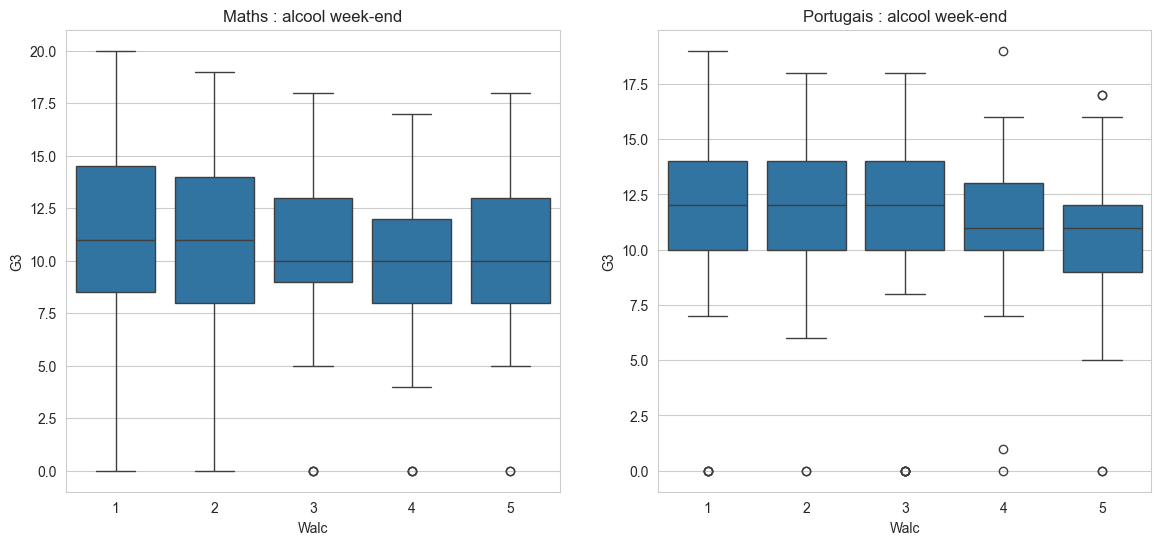

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.boxplot(
    x="Walc",
    y="G3",
    data=df_mat,
    ax=axes[0]
)

axes[0].set_title("Maths : alcool week-end")

sns.boxplot(
    x="Walc",
    y="G3",
    data=df_por,
    ax=axes[1]
)

axes[1].set_title("Portugais : alcool week-end")

plt.show()

Absences vs notes

Cette cellule trace l'évolution de G3 en fonction du nombre d'absences pour identifier l'impact de l'assiduité.

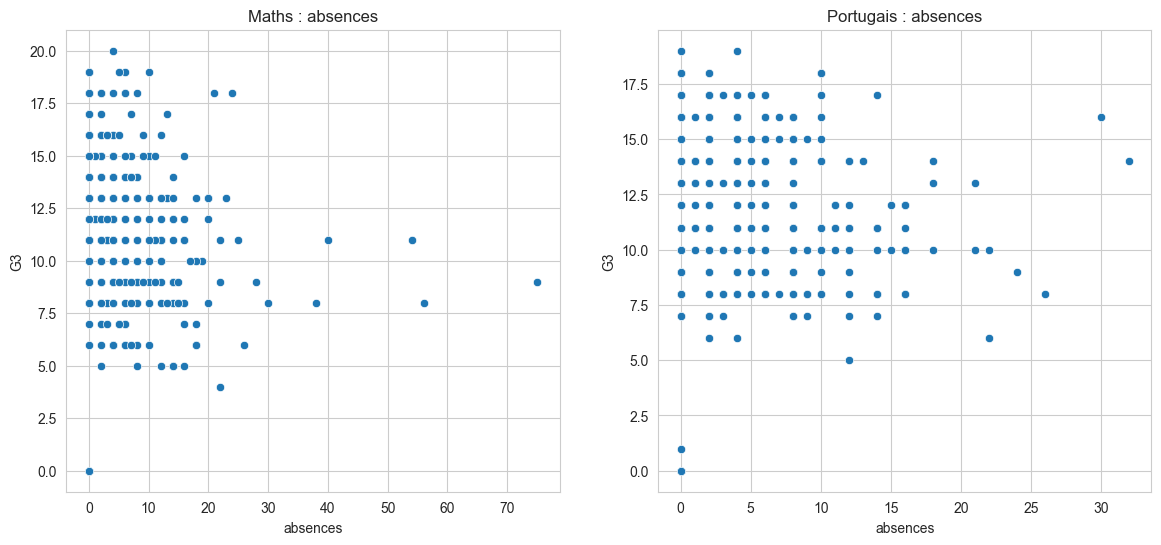

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.scatterplot(
    x="absences",
    y="G3",
    data=df_mat,
    ax=axes[0]
)

axes[0].set_title("Maths : absences")

sns.scatterplot(
    x="absences",
    y="G3",
    data=df_por,
    ax=axes[1]
)

axes[1].set_title("Portugais : absences")

plt.show()

Ce bloc compare les notes G3 selon le sexe de l'étudiant, pour visualiser si des différences de performance apparaissent entre filles et garçons.

Ce bloc conclut l'analyse des absences en montrant les corrélations entre absences, distribution et moyenne de G3.

## Analyse détaillée : Facteurs de performance

C:\Users\HKHD\AppData\Local\Temp\ipykernel_5576\3523672480.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Dalc", y="G3", data=df_mat, ax=axes[0, 0], palette="Set2")
C:\Users\HKHD\AppData\Local\Temp\ipykernel_5576\3523672480.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Dalc", y="G3", data=df_por, ax=axes[0, 1], palette="Set2")
C:\Users\HKHD\AppData\Local\Temp\ipykernel_5576\3523672480.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Walc", y="G3", data=df_mat, ax=axes[1, 0], palette="Set3")
C:\Users\HKHD\AppData\Loca

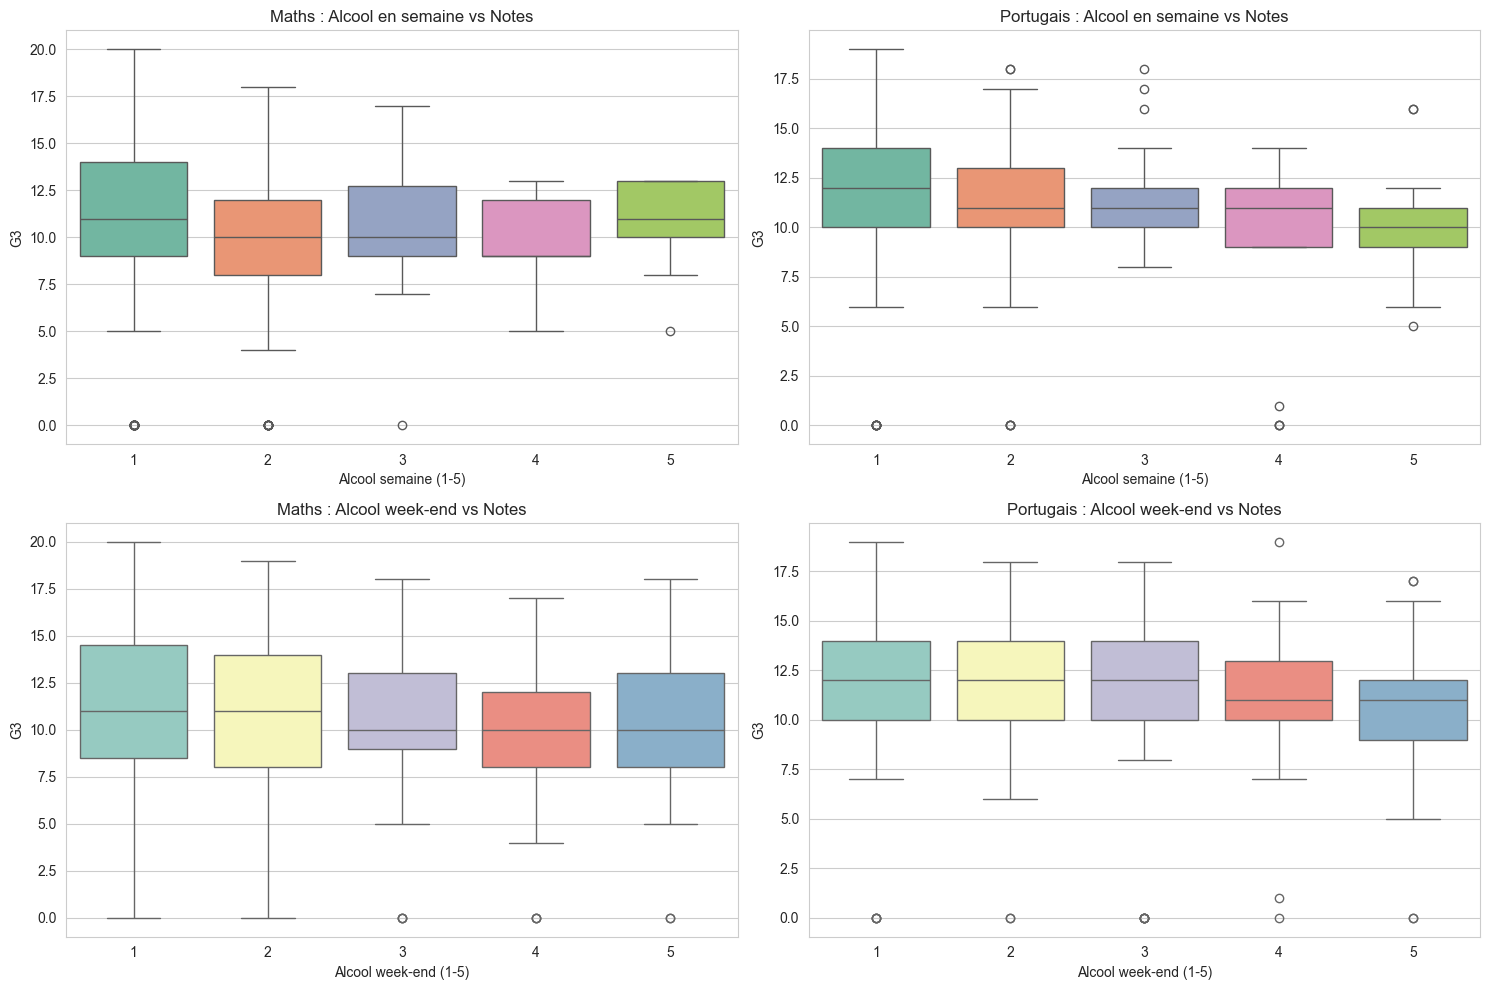

=== Statistiques Alcool ===

Maths - Moyenne G3 par Dalc:
           mean       std  count
Dalc                            
1     10.731884  4.676502    276
2      9.253333  4.812970     75
3     10.500000  3.443835     26
4      9.888889  2.619372      9
5     10.666667  2.692582      9

Maths - Moyenne G3 par Walc:
           mean       std  count
Walc                            
1     10.735099  5.133812    151
2     10.082353  4.950257     85
3     10.725000  3.700753     80
4      9.686275  3.619338     51
5     10.142857  4.125030     28


In [6]:
### 1. Consommation d'alcool (Jour vs Weekend)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Workday alcohol (Dalc) vs G3
sns.boxplot(x="Dalc", y="G3", data=df_mat, ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Maths : Alcool en semaine vs Notes")
axes[0, 0].set_xlabel("Alcool semaine (1-5)")

sns.boxplot(x="Dalc", y="G3", data=df_por, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Portugais : Alcool en semaine vs Notes")
axes[0, 1].set_xlabel("Alcool semaine (1-5)")

# Weekend alcohol (Walc) vs G3
sns.boxplot(x="Walc", y="G3", data=df_mat, ax=axes[1, 0], palette="Set3")
axes[1, 0].set_title("Maths : Alcool week-end vs Notes")
axes[1, 0].set_xlabel("Alcool week-end (1-5)")

sns.boxplot(x="Walc", y="G3", data=df_por, ax=axes[1, 1], palette="Set3")
axes[1, 1].set_title("Portugais : Alcool week-end vs Notes")
axes[1, 1].set_xlabel("Alcool week-end (1-5)")

plt.tight_layout()
plt.show()

# Statistiques d'alcool
print("=== Statistiques Alcool ===")
print("\nMaths - Moyenne G3 par Dalc:")
print(df_mat.groupby("Dalc")["G3"].agg(["mean", "std", "count"]))
print("\nMaths - Moyenne G3 par Walc:")
print(df_mat.groupby("Walc")["G3"].agg(["mean", "std", "count"]))


C:\Users\HKHD\AppData\Local\Temp\ipykernel_5576\1578001194.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Medu", y="G3", data=df_mat, ax=axes[0, 0], palette="Blues")
C:\Users\HKHD\AppData\Local\Temp\ipykernel_5576\1578001194.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Medu", y="G3", data=df_por, ax=axes[0, 1], palette="Blues")
C:\Users\HKHD\AppData\Local\Temp\ipykernel_5576\1578001194.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Fedu", y="G3", data=df_mat, ax=axes[1, 0], palette="Greens")
C:\Users\HKHD\AppData\

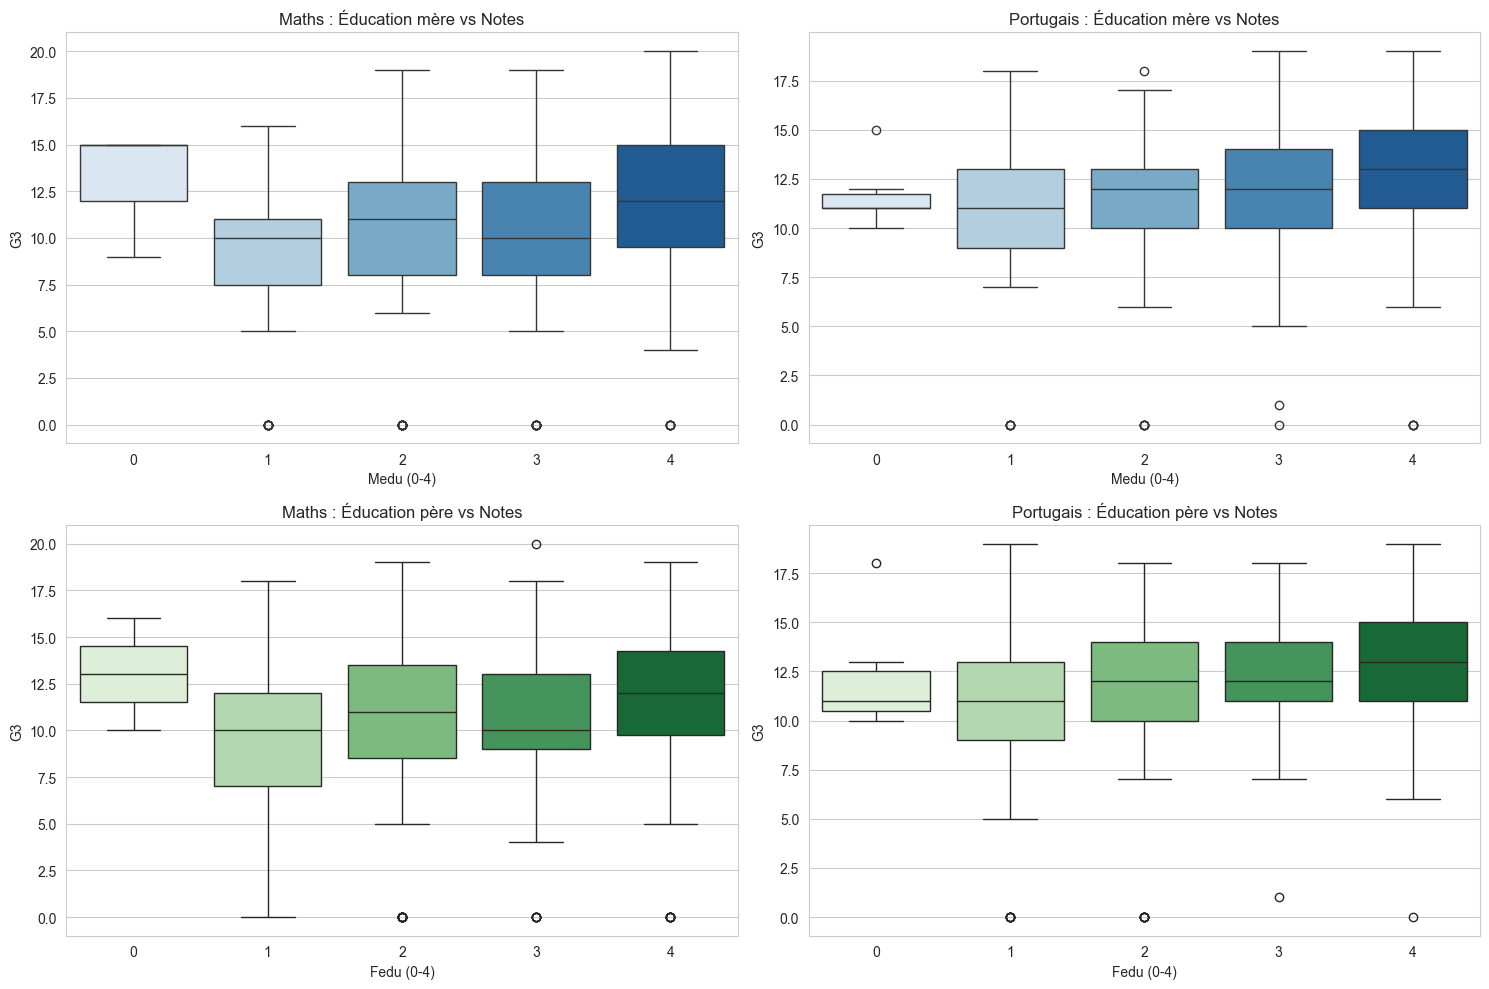

=== Statistiques Éducation Parents ===

Maths - Moyenne G3 par Medu:
           mean       std  count
Medu                            
0     13.000000  3.464102      3
1      8.677966  4.364594     59
2      9.728155  4.636163    103
3     10.303030  4.623486     99
4     11.763359  4.267646    131

Maths - Moyenne G3 par Fedu:
           mean       std  count
Fedu                            
0     13.000000  4.242641      2
1      9.158537  4.563596     82
2     10.260870  4.733396    115
3     10.660000  4.149285    100
4     11.364583  4.665934     96


In [7]:
### 2. Niveau d'éducation des parents

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Mother education
sns.boxplot(x="Medu", y="G3", data=df_mat, ax=axes[0, 0], palette="Blues")
axes[0, 0].set_title("Maths : Éducation mère vs Notes")
axes[0, 0].set_xlabel("Medu (0-4)")

sns.boxplot(x="Medu", y="G3", data=df_por, ax=axes[0, 1], palette="Blues")
axes[0, 1].set_title("Portugais : Éducation mère vs Notes")
axes[0, 1].set_xlabel("Medu (0-4)")

# Father education
sns.boxplot(x="Fedu", y="G3", data=df_mat, ax=axes[1, 0], palette="Greens")
axes[1, 0].set_title("Maths : Éducation père vs Notes")
axes[1, 0].set_xlabel("Fedu (0-4)")

sns.boxplot(x="Fedu", y="G3", data=df_por, ax=axes[1, 1], palette="Greens")
axes[1, 1].set_title("Portugais : Éducation père vs Notes")
axes[1, 1].set_xlabel("Fedu (0-4)")

plt.tight_layout()
plt.show()

# Statistiques
print("=== Statistiques Éducation Parents ===")
print("\nMaths - Moyenne G3 par Medu:")
print(df_mat.groupby("Medu")["G3"].agg(["mean", "std", "count"]))
print("\nMaths - Moyenne G3 par Fedu:")
print(df_mat.groupby("Fedu")["G3"].agg(["mean", "std", "count"]))


C:\Users\HKHD\AppData\Local\Temp\ipykernel_5576\4069892451.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Mjob", y="G3", data=df_mat, ax=axes[0, 0], palette="Reds")
C:\Users\HKHD\AppData\Local\Temp\ipykernel_5576\4069892451.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Mjob", y="G3", data=df_por, ax=axes[0, 1], palette="Reds")
C:\Users\HKHD\AppData\Local\Temp\ipykernel_5576\4069892451.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Fjob", y="G3", data=df_mat, ax=axes[1, 0], palette="Oranges")
C:\Users\HKHD\AppData\L

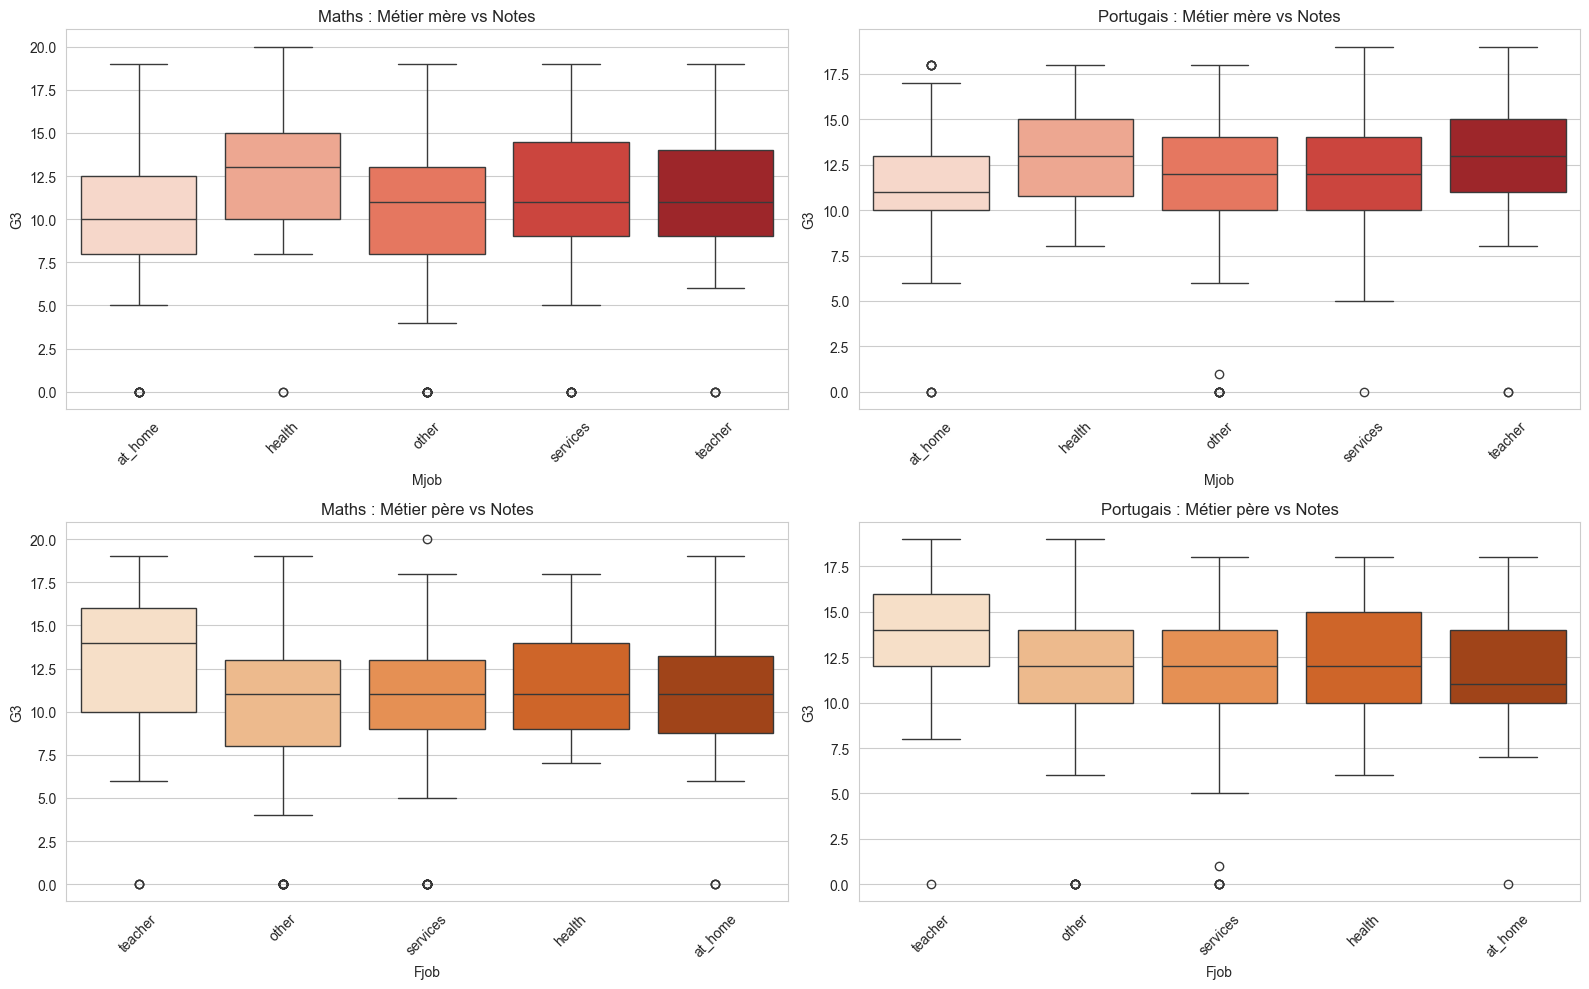

=== Statistiques Travail Parents ===

Maths - Moyenne G3 par Mjob:
           mean   std  count
Mjob                        
at_home    9.15  4.73     59
health    12.15  4.23     34
other      9.82  4.36    141
services  11.02  4.76    103
teacher   11.05  4.40     58

Maths - Moyenne G3 par Fjob:
           mean   std  count
Fjob                        
at_home   10.15  5.32     20
health    11.61  3.24     18
other     10.19  4.51    217
services  10.30  4.48    111
teacher   11.97  5.49     29


In [8]:
### 3. Travail des parents

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Mother job
sns.boxplot(x="Mjob", y="G3", data=df_mat, ax=axes[0, 0], palette="Reds")
axes[0, 0].set_title("Maths : Métier mère vs Notes")
axes[0, 0].tick_params(axis='x', rotation=45)

sns.boxplot(x="Mjob", y="G3", data=df_por, ax=axes[0, 1], palette="Reds")
axes[0, 1].set_title("Portugais : Métier mère vs Notes")
axes[0, 1].tick_params(axis='x', rotation=45)

# Father job
sns.boxplot(x="Fjob", y="G3", data=df_mat, ax=axes[1, 0], palette="Oranges")
axes[1, 0].set_title("Maths : Métier père vs Notes")
axes[1, 0].tick_params(axis='x', rotation=45)

sns.boxplot(x="Fjob", y="G3", data=df_por, ax=axes[1, 1], palette="Oranges")
axes[1, 1].set_title("Portugais : Métier père vs Notes")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Statistiques
print("=== Statistiques Travail Parents ===")
print("\nMaths - Moyenne G3 par Mjob:")
print(df_mat.groupby("Mjob")["G3"].agg(["mean", "std", "count"]).round(2))
print("\nMaths - Moyenne G3 par Fjob:")
print(df_mat.groupby("Fjob")["G3"].agg(["mean", "std", "count"]).round(2))


C:\Users\HKHD\AppData\Local\Temp\ipykernel_5576\411237775.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="sex", y="G3", data=df_mat, palette="Set1", ax=axes[0])
C:\Users\HKHD\AppData\Local\Temp\ipykernel_5576\411237775.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="sex", y="G3", data=df_por, palette="Set1", ax=axes[1])


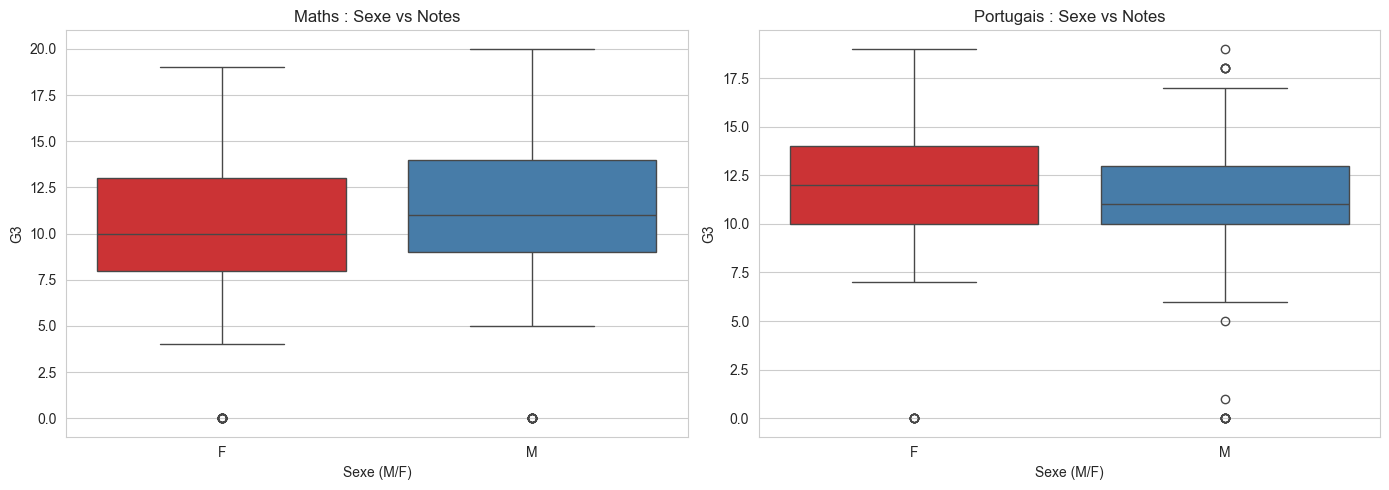

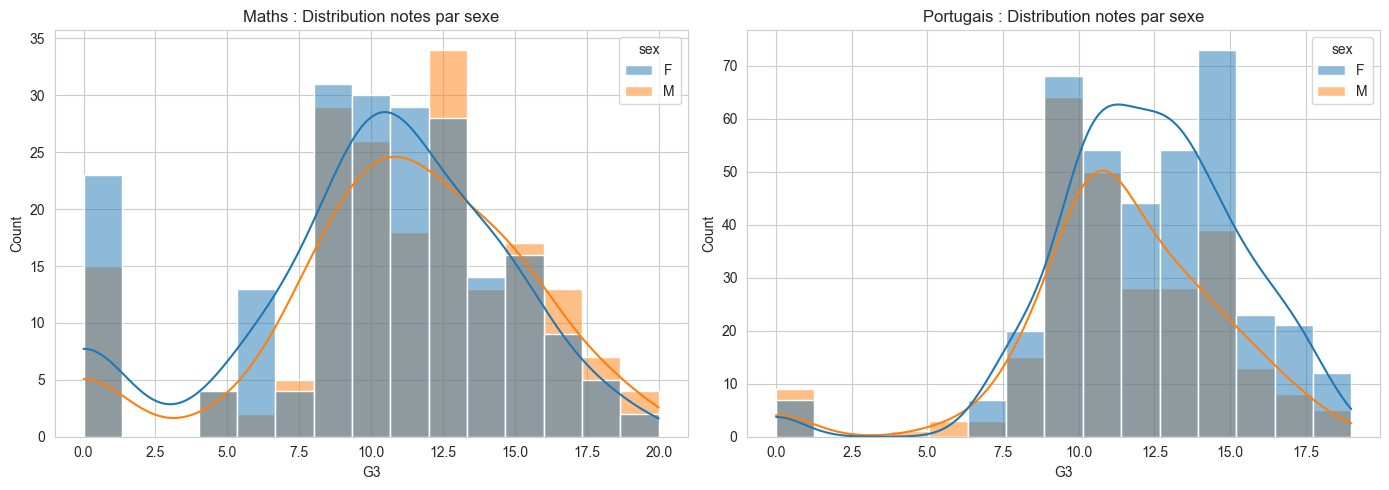

=== Statistiques Sexe ===

Maths - Moyenne G3 par sexe:
      mean   std  count
sex                    
F     9.97  4.62    208
M    10.91  4.50    187

Portugais - Moyenne G3 par sexe:
      mean   std  count
sex                    
F    12.25  3.12    383
M    11.41  3.32    266


In [ ]:
### 4. Sexe de l'étudiant

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="sex", y="G3", data=df_mat, palette="Set1", ax=axes[0])
axes[0].set_title("Maths : Sexe vs Notes")
axes[0].set_xlabel("Sexe (M/F)")

sns.boxplot(x="sex", y="G3", data=df_por, palette="Set1", ax=axes[1])
axes[1].set_title("Portugais : Sexe vs Notes")
axes[1].set_xlabel("Sexe (M/F)")

plt.tight_layout()
plt.show()

# Distribution par sexe
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_mat, x="G3", hue="sex", kde=True, ax=axes[0], bins=15)
axes[0].set_title("Maths : Distribution notes par sexe")

sns.histplot(data=df_por, x="G3", hue="sex", kde=True, ax=axes[1], bins=15)
axes[1].set_title("Portugais : Distribution notes par sexe")

plt.tight_layout()
plt.show()

# Statistiques
print("=== Statistiques Sexe ===")
print("\nMaths - Moyenne G3 par sexe:")
print(df_mat.groupby("sex")["G3"].agg(["mean", "std", "count"]).round(2))
print("\nPortugais - Moyenne G3 par sexe:")
print(df_por.groupby("sex")["G3"].agg(["mean", "std", "count").round(2))


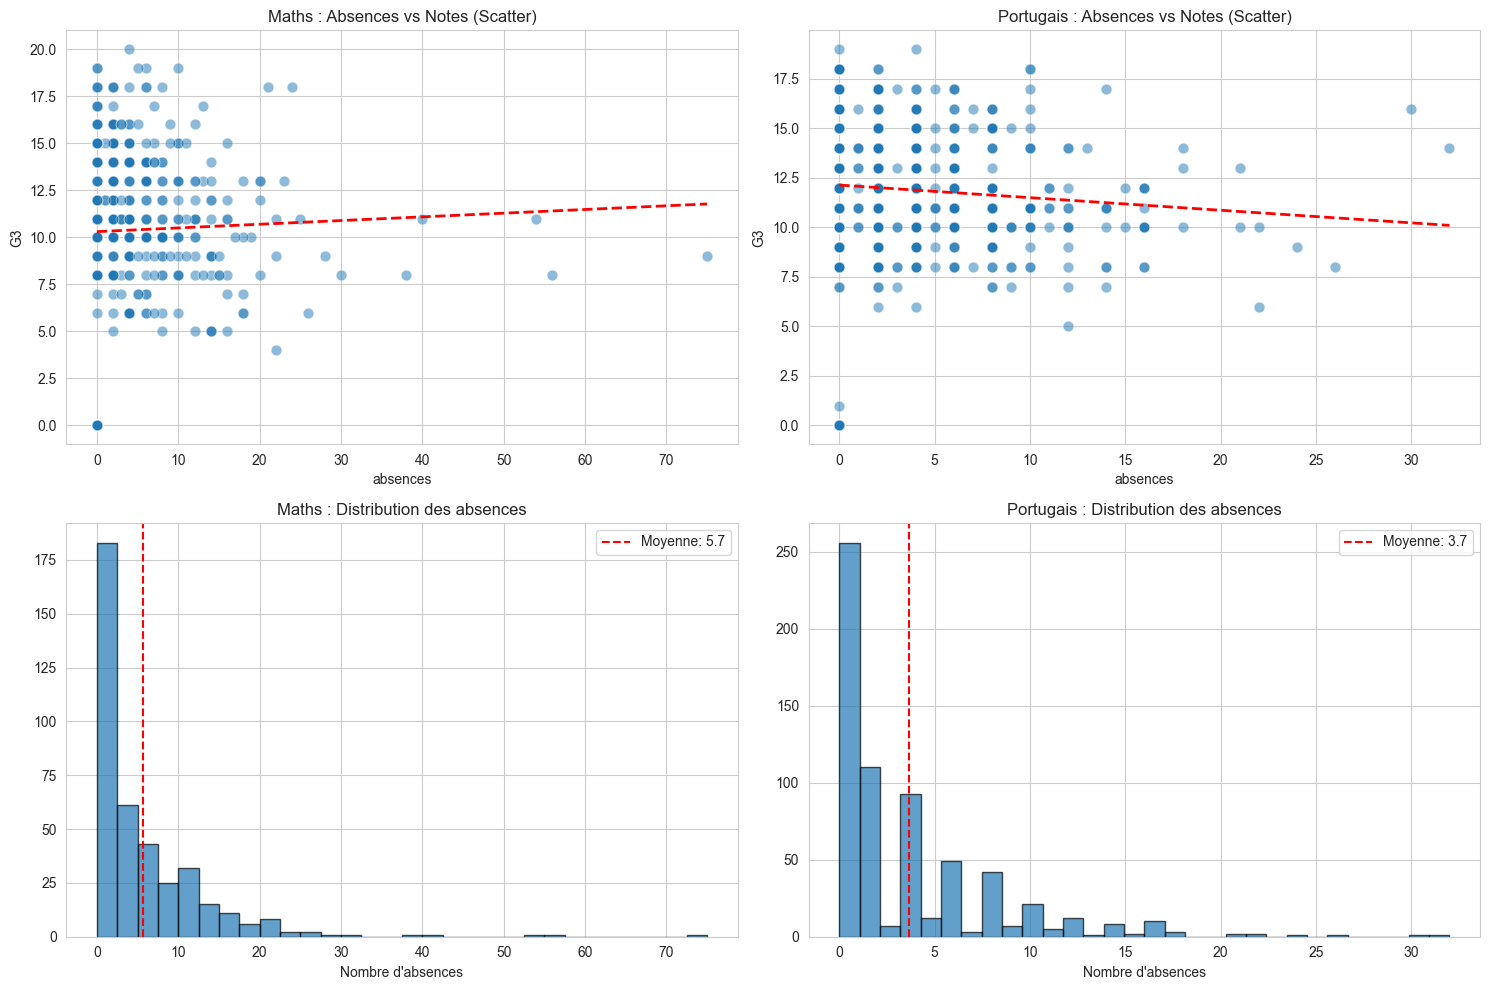

=== Corrélation Absences vs G3 ===
Maths : 0.034
Portugais : -0.091

Maths - Moyenne G3 par quartile d'absences:
                   mean   std  count
absence_quartile                    
(-0.001, 4.0]     10.14  5.19    244
(4.0, 8.0]        11.37  3.40     65
(8.0, 75.0]       10.48  3.24     86


In [10]:
### 5. Absences détaillées

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Scatter plots
sns.scatterplot(x="absences", y="G3", data=df_mat, alpha=0.5, ax=axes[0, 0], s=60)
axes[0, 0].set_title("Maths : Absences vs Notes (Scatter)")
z = np.polyfit(df_mat["absences"], df_mat["G3"], 1)
p = np.poly1d(z)
axes[0, 0].plot(df_mat["absences"].sort_values(), p(df_mat["absences"].sort_values()), "r--", linewidth=2)

sns.scatterplot(x="absences", y="G3", data=df_por, alpha=0.5, ax=axes[0, 1], s=60)
axes[0, 1].set_title("Portugais : Absences vs Notes (Scatter)")
z = np.polyfit(df_por["absences"], df_por["G3"], 1)
p = np.poly1d(z)
axes[0, 1].plot(df_por["absences"].sort_values(), p(df_por["absences"].sort_values()), "r--", linewidth=2)

# Distribution d'absences
axes[1, 0].hist(df_mat["absences"], bins=30, alpha=0.7, edgecolor='black')
axes[1, 0].set_title("Maths : Distribution des absences")
axes[1, 0].set_xlabel("Nombre d'absences")
axes[1, 0].axvline(df_mat["absences"].mean(), color='red', linestyle='--', label=f'Moyenne: {df_mat["absences"].mean():.1f}')
axes[1, 0].legend()

axes[1, 1].hist(df_por["absences"], bins=30, alpha=0.7, edgecolor='black')
axes[1, 1].set_title("Portugais : Distribution des absences")
axes[1, 1].set_xlabel("Nombre d'absences")
axes[1, 1].axvline(df_por["absences"].mean(), color='red', linestyle='--', label=f'Moyenne: {df_por["absences"].mean():.1f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Corrélation
print("=== Corrélation Absences vs G3 ===")
corr_mat_abs = df_mat[["absences", "G3"]].corr().iloc[0, 1]
corr_por_abs = df_por[["absences", "G3"]].corr().iloc[0, 1]
print(f"Maths : {corr_mat_abs:.3f}")
print(f"Portugais : {corr_por_abs:.3f}")

# Grouper par quartiles d'absences
print("\nMaths - Moyenne G3 par quartile d'absences:")
df_mat["absence_quartile"] = pd.qcut(df_mat["absences"], q=4, duplicates='drop')
print(df_mat.groupby("absence_quartile")["G3"].agg(["mean", "std", "count"]).round(2))
